## Final enhancement segmentation pipeline 

Detected Mode: alligator
Processing started.. Mode is alligator
Processed 30 frames...
Displaying frames comparison


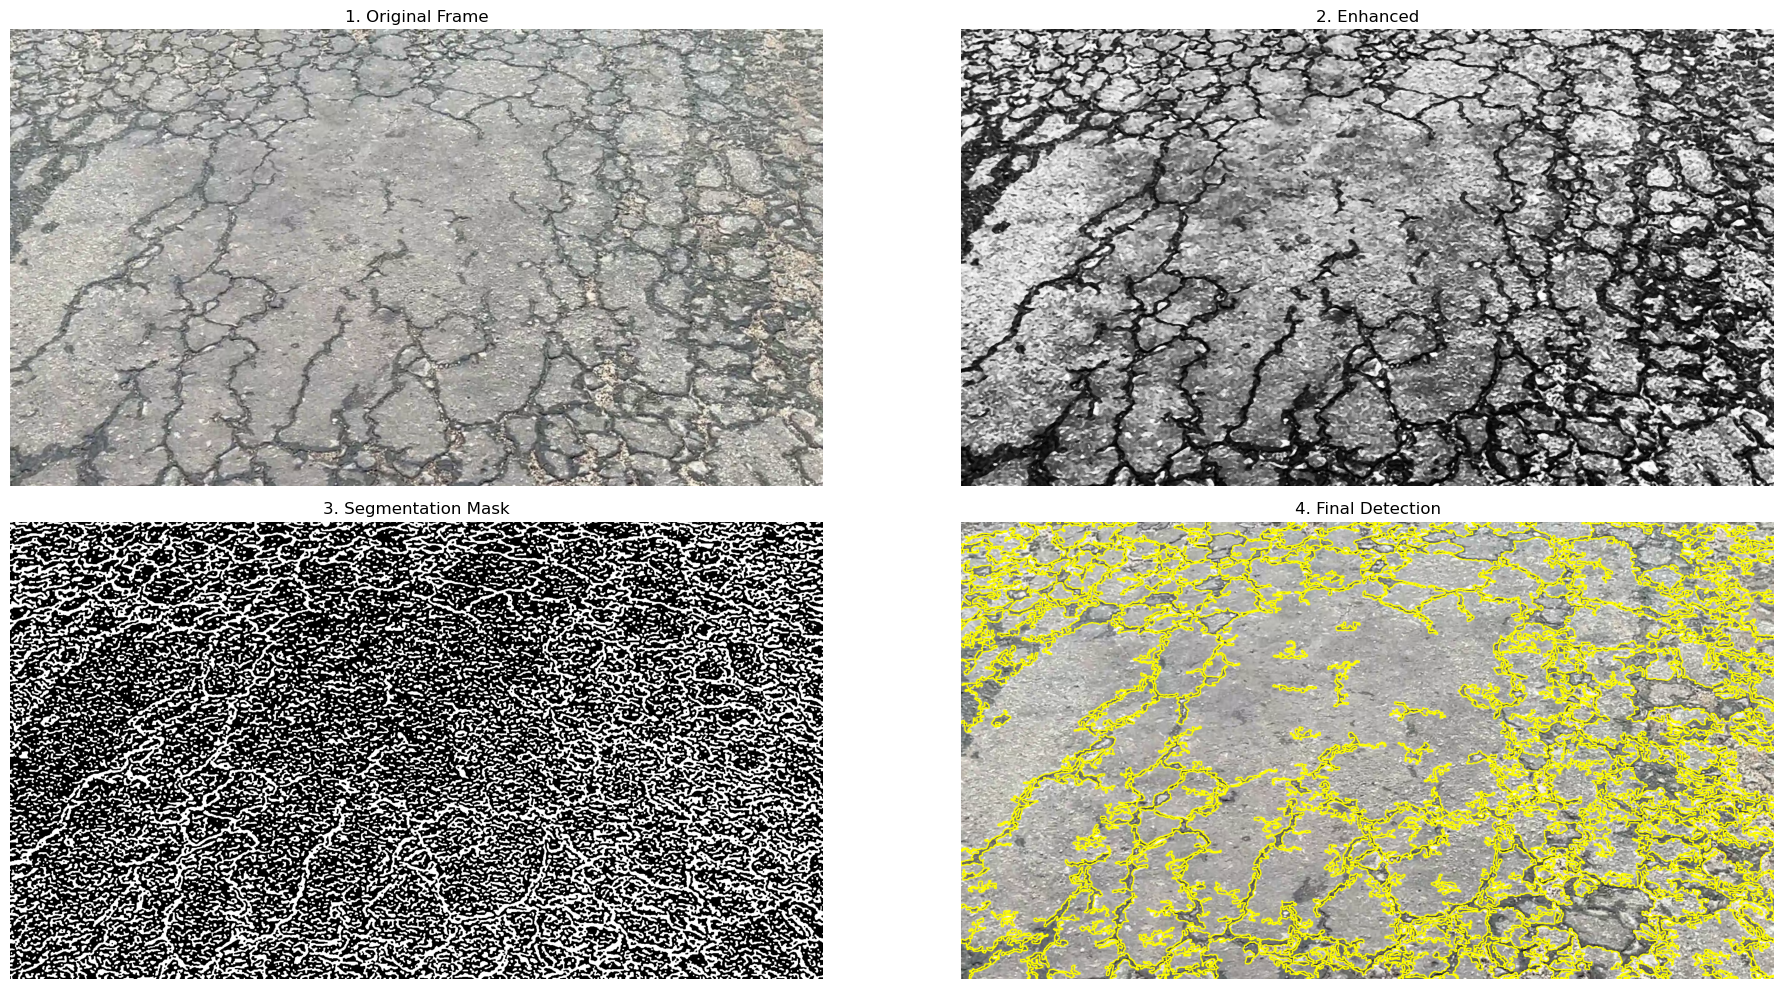

Processed 60 frames...
Processed 90 frames...
Processed 120 frames...
Processed 150 frames...
Processed 180 frames...
Processed 210 frames...
Processed 240 frames...
Processed 270 frames...
Processed 300 frames...
Processed 330 frames...
Processed 360 frames...
Done! Output saved as: Alligater_crack._final_detection_output.mp4


In [7]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Enter the input video pth 
video_path = "Alligater_crack.mp4" 
# Enter the output video pth
output_video_name = "Alligater_crack._final_detection_output.mp4"

# Get the filename from the video path and convert it to lowercase for easy matching
filename_lower = os.path.basename(video_path).lower()

if "alligator" in filename_lower:
    MODE = "alligator"
elif "pothole" in filename_lower:
    MODE = "pothole"
elif "raveling" in filename_lower:
    MODE = "raveling"
elif "edge" in filename_lower:
    MODE = "edge"
else:
    MODE = "alligator"

# print what the mode detected 
print(f"Detected Mode: {MODE}")

# function for enhancement 
def enhance_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    equalized = cv2.equalizeHist(gray)
    gaussian = cv2.GaussianBlur(equalized, (5, 5), 1.0)
    median = cv2.medianBlur(gaussian, 5)
    # Apply laplacian | convert image type (int to float) for appply laplacian 
    laplacian = cv2.Laplacian(median, cv2.CV_64F)
    sharpened = median - laplacian
    # Convert float image to int again for understand to the machine
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    return sharpened

# function for detection and segmentation 
def apply_detection(enhanced_img, original_frame, mode):
    # Initialize the mask variable with nothing (None) so it can be used later
    mask = None
    # Set a default color (Red) to ensure the code has a color to use even if the mode is not recognized
    color = (0, 0, 255) 

    # A small 3x3 square matrix used to remove tiny noise or dots from the image
    small_kernel = np.ones((3, 3), np.uint8)
    # A larger 7x7 elliptical shape used to bridge gaps and smooth the detected crack areas
    large_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    if mode == "pothole":
        _, thresh = cv2.threshold(enhanced_img, 60, 255, cv2.THRESH_BINARY_INV)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, small_kernel, iterations=2)
        closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, large_kernel, iterations=2)
        mask = cv2.erode(cv2.dilate(closing, large_kernel, iterations=1), small_kernel, iterations=1)
        color = (0, 0, 255)
    elif mode == "alligator":
        thresh = cv2.adaptiveThreshold(enhanced_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5)
        clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3)))
        mask = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, np.ones((3,3)))
        color = (0, 255, 255)
    elif mode == "raveling":
        _, thresh = cv2.threshold(enhanced_img, 60, 255, cv2.THRESH_BINARY_INV)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, small_kernel, iterations=2)
        mask = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, large_kernel, iterations=2)
        color = (0, 255, 255)
    elif mode == "edge":
        _, thresh = cv2.threshold(enhanced_img, 80, 255, cv2.THRESH_BINARY_INV)
        opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, small_kernel, iterations=2)
        closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, large_kernel, iterations=2)
        mask = cv2.erode(cv2.dilate(closing, large_kernel, iterations=1), small_kernel, iterations=1)
        color = (0, 255, 255)

    # Create a copy of the original image to draw detections on, without changing the original frame
    detection_frame = original_frame.copy()
    # 'contours' holds the crack shapes; the '_' just ignores extra details we don't need
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Loop through each detected crack outline one by one
    for crack in contours:
        # Calculate the size (area) of the current crack in pixels
        area = cv2.contourArea(crack)
        # Set a minimum size limit to ignore unimportant dots (noise)
        min_area = 3000 if mode == "pothole" else 500 

        # Skip small dots and only keep the big cracks
        if area > min_area:
            # For these specific cracks, draw the exact outline (shape)
            if mode in ["alligator", "raveling", "edge"]:
                # -1 means draw all contours in the provided list
                cv2.drawContours(detection_frame, [crack], -1, color, 2)
            # For other modes (like potholes) draw a simple rectangle box around it
            else:
                # Get the coordinates and size (x, y, width, height) to fit a box around the crack
                x, y, w, h = cv2.boundingRect(crack)
                # Draw the actual rectangle box on the image using those coordinates
                cv2.rectangle(detection_frame, (x, y), (x + w, y + h), color, 2)

    return mask, detection_frame



## MAIN PROCESSING PIPELINE

# Open the video file from the given path
cap = cv2.VideoCapture(video_path)
# Check video is opened or not
if not cap.isOpened():
    print("Error: cannot open the video")
    exit()

# Get video properties: Frames Per Second, Width, Height
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Set the video format to MP4 and create the file to save our results
video_format = cv2.VideoWriter_fourcc(*'mp4v')
output_file = cv2.VideoWriter(output_video_name, video_format, fps, (width, height))

frame_count = 0
print(f"Processing started.. Mode is {MODE}")


while True:
    # Read the next frame from the video; 'ret' is True or False, 'frame' is the image data
    ret, frame = cap.read()
    if not ret:
        break

    # call the function for enhancement
    enhanced = enhance_frame(frame)
    
    # function for detection and segmentation: Detect cracks/potholes and get the black and white mask and the final drawn frame
    mask, result = apply_detection(enhanced, frame, MODE)


    
    # Display a sample frame for how the sytem working
    if frame_count == 30:
        print("Displaying frames comparison")
        plt.figure(figsize=(20, 10))
        
        titles = ['1. Original Frame', '2. Enhanced', '3. Segmentation Mask', '4. Final Detection']
        # OpenCV use BGR. need to convert RGB for matplotlib
        images = [ cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), 
                   enhanced, 
                   mask, 
                   cv2.cvtColor(result, cv2.COLOR_BGR2RGB) 
                 ]
        
        # Loop 4 times to display all 4 processing stages side-by-side
        for i in range(4):
            # Create a space for each image in a grid (2 rows, 2 columns)
            # i+1 is used because Matplotlib subplot positions start from 1, while Python loops start from 0
            plt.subplot(2, 2, i+1)
            # Show the image; use grayscale mode for enhanced and mask frames (index 1 and 2)
            plt.imshow(images[i], cmap='gray' if i in [1, 2] else None)
            plt.title(titles[i])
            # Hide the x and y axis numbers to keep the image clean
            plt.axis('off') 
        
        plt.tight_layout()
        plt.show() #show all frames


    
    # save the final processed frame into the new video file
    output_file.write(result)

    # Increase the frame counter by 1
    frame_count = frame_count + 1
    
    # Every 30 frames, print progress to the console for knowing algorithm is running 
    if frame_count % 30 == 0:
        print(f"Processed {frame_count} frames...")

# Release the input video file when finished
cap.release()
# Save and close the final output video file
output_file.release()

print(f"Done! Output saved as: {output_video_name}")